# **CSL2050: Pattern Recognition and Machine Learning**
## **Course Project: Hand-drawn Sketch Recognition**

### **Step 1:** Importing the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# Define paths
zip_path = "/content/drive/My Drive/Dataset_PNG.zip"  # Space in "My Drive" is fine here
extract_path = "/content/Dataset_PNG"

# Create extract folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
print(os.listdir(extract_path))

Mounted at /content/drive
['sketches_png']


In [ ]:
!apt-get install unzip -y
!unzip "/content/drive/My Drive/Dataset_PNG.zip" -d /content/Dataset_PNG

Streaming output truncated to the last 5000 lines.
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15001.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15002.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15003.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15004.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15005.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15006.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15007.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15008.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15009.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15010.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15011.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15012.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15013.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15014.png

In [ ]:
dataset_path = "/content/Dataset_PNG/sketches_png/png"

# Check the extracted dataset folder
print(os.listdir(dataset_path))  # Should show category folders like 'zebra', 'cat', etc.

# Check some images inside a category
sample_category = os.path.join(dataset_path, "zebra")  # Change to any category name
print(os.listdir(sample_category)[:5])  # List first 5 images

['mushroom', 'house', 'cup', 'suitcase', 'mosquito', 'tv', 'revolver', 'calculator', 'wineglass', 'telephone', 'snowman', 'head-phones', 'bookshelf', 'duck', 'sheep', 'megaphone', 'snail', 'feather', 'comb', 'pumpkin', 'spoon', 'cactus', 'tooth', 'bear (animal)', 'tablelamp', 'foot', 'armchair', 'teacup', 'zebra', 'grapes', 'blimp', 'seagull', 'pen', 'mouse (animal)', 'sponge bob', 'space shuttle', 'cake', 'ashtray', 'eye', 'axe', 'wheelbarrow', 'pipe (for smoking)', 'leaf', 'couch', 'table', 'cell phone', 'syringe', 'hammer', 'traffic light', 'fish', 'door handle', 'cigarette', 'suv', 'bread', 'present', 'speed-boat', 'vase', 'owl', 'pig', 'socks', 'door', 'barn', 'cloud', 'helicopter', 'dolphin', 'kangaroo', 'rooster', 'head', 'standing bird', 'castle', 'rifle', 'satellite', 'screwdriver', 'microscope', 'motorbike', 'cow', 'crocodile', 'flashlight', 'bee', 'sailboat', 'sea turtle', 'boomerang', 'camel', 'bell', 'teapot', 'monkey', 'parrot', 'canoe', 'baseball bat', 'skull', 'nose', '

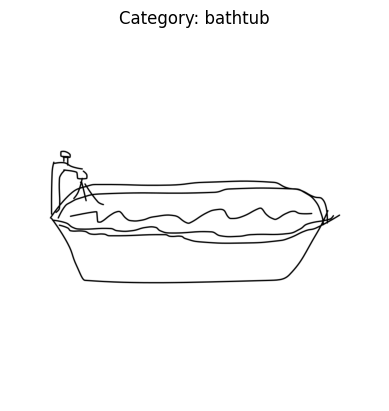

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

# Pick a random category
categories = os.listdir(dataset_path)
random_category = random.choice(categories)

# Pick a random image from the category
image_folder = os.path.join(dataset_path, random_category)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# Load and display the image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
plt.imshow(image, cmap='gray')
plt.title(f"Category: {random_category}")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
categories = os.listdir(dataset_path)
data = []
labels = []
for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
        img = cv2.resize(img, (64, 64))  # Resize to 64x64
        data.append(img.flatten())  # Flatten the image to a 1D array
        labels.append(category)

# Convert to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog

# Reshape 'data' correctly to match the original image dimensions
# Assuming your original images were 64x64, you should reshape like this:
data_reshaped = data.reshape(-1, 64, 64)

# Compute HOG features
data_hog = []
for img in data_reshaped:  # Iterate over the reshaped data
    hog_features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    data_hog.append(hog_features)
data_hog = np.array(data_hog)
print(f"HOG feature size: {data_hog.shape}")

# Split and scale (now with consistent shapes)
X_train_hog, X_test_hog, y_train, y_test = train_test_split(data_hog, labels, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_hog_scaled = scaler.fit_transform(X_train_hog)
X_test_hog_scaled = scaler.transform(X_test_hog)

# Train KNN with distance weighting
knn = KNeighborsClassifier(n_neighbors=10, weights='distance')
knn.fit(X_train_hog_scaled, y_train)
y_pred = knn.predict(X_test_hog_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy with HOG and distance weighting (k=10): {accuracy:.2f}")
print(f"Predicted labels (sample): {y_pred[:10]}")
print(f"True labels (sample): {y_test[:10]}")

HOG feature size: (20000, 1764)
KNN Accuracy with HOG and distance weighting (k=10): 0.06
Predicted labels (sample): [ 89  73 107 188 144 196 204 188 216  44]
True labels (sample): [193 218 109 160 203 132  71 188 247  32]


random forest with feature extraction using raw pixel data

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load raw pixel data
def load_raw_features(dataset_path, max_samples=100):
    categories = os.listdir(dataset_path)
    X, y = [], []

    for category in tqdm(categories):
        cat_path = os.path.join(dataset_path, category)
        samples = 0

        for img_name in os.listdir(cat_path)[:max_samples]:
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (128, 128))  # Fixed size
            img = img / 255.0  # Normalize
            X.append(img.flatten())  # Flatten to 1D array
            y.append(category)
            samples += 1

            if samples >= max_samples:
                break

    return np.array(X), np.array(y)

# Load data
dataset_path = "/content/Dataset_PNG/sketches_png/png"  # Update path as needed
X, y = load_raw_features(dataset_path, max_samples=100)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=15,      # Limit depth
    random_state=42,
    n_jobs=-1          # Use all cores
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy (Raw Pixels): {accuracy:.4f}")

# Classification report
print("\nBalanced Accuracy Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

100%|██████████| 250/250 [01:04<00:00,  3.86it/s]


Random Forest Accuracy (Raw Pixels): 0.0330

Balanced Accuracy Report:
                    precision    recall  f1-score   support

          airplane       0.00      0.00      0.00        16
       alarm clock       0.00      0.00      0.00        16
             angel       0.07      0.06      0.07        16
               ant       0.00      0.00      0.00        16
             apple       0.06      0.06      0.06        16
               arm       0.00      0.00      0.00        16
          armchair       0.00      0.00      0.00        16
           ashtray       0.00      0.00      0.00        16
               axe       0.00      0.00      0.00        16
          backpack       0.00      0.00      0.00        16
            banana       0.00      0.00      0.00        16
              barn       0.00      0.00      0.00        16
      baseball bat       0.07      0.31      0.11        16
            basket       0.00      0.00      0.00        16
           bathtub       0.0

random forest+CNN

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load pretrained ResNet50 model for feature extraction
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the model

# Batch feature extraction using CNN
def extract_cnn_features_batch(images):
    images_preprocessed = preprocess_input(images)
    features = base_model.predict(images_preprocessed, verbose=0)
    return features

# Load data with CNN features
def load_cnn_features(dataset_path, max_samples=100, batch_size=32):
    categories = os.listdir(dataset_path)
    X, y = [], []

    for category in tqdm(categories, desc="Loading categories"):
        cat_path = os.path.join(dataset_path, category)
        samples = 0
        batch_images = []

        for img_name in os.listdir(cat_path)[:max_samples]:
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            # Convert grayscale to RGB for ResNet50
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            img_resized = cv2.resize(img_rgb, (224, 224))
            batch_images.append(img_resized)
            samples += 1

            # Process batch when full or at the end
            if len(batch_images) == batch_size or (samples == max_samples and batch_images):
                batch_array = np.array(batch_images)
                features = extract_cnn_features_batch(batch_array)
                X.extend(features)
                y.extend([category] * len(features))
                batch_images = []

            if samples >= max_samples:
                break

        # Process remaining images
        if batch_images:
            batch_array = np.array(batch_images)
            features = extract_cnn_features_batch(batch_array)
            X.extend(features)
            y.extend([category] * len(features))

    return np.array(X), np.array(y)

# Load data
dataset_path = "/content/Dataset_PNG/sketches_png/png"  # Update path as needed
X, y = load_cnn_features(dataset_path, max_samples=100, batch_size=32)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=15,      # Limit depth
    random_state=42,
    n_jobs=-1          # Use all cores
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest with CNN Accuracy: {accuracy:.4f}")

# Classification report
print("\nBalanced Accuracy Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Loading categories: 100%|██████████| 250/250 [03:56<00:00,  1.06it/s]


Random Forest with CNN Accuracy: 0.3917

Balanced Accuracy Report:
                    precision    recall  f1-score   support

          airplane       0.14      0.06      0.09        16
       alarm clock       0.30      0.38      0.33        16
             angel       0.10      0.06      0.08        16
               ant       0.29      0.12      0.17        16
             apple       0.39      0.94      0.56        16
               arm       0.33      0.12      0.18        16
          armchair       0.25      0.19      0.21        16
           ashtray       0.20      0.06      0.10        16
               axe       0.44      0.50      0.47        16
          backpack       0.30      0.44      0.36        16
            banana       0.33      0.25      0.29        16
              barn       0.25      0.12      0.17        16
      baseball bat       0.33      0.81      0.47        16
            basket       0.50      0.38      0.43        16
           bathtub       0.44   

randomforest+hog

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from skimage.feature import hog
from tqdm import tqdm
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# HOG feature extraction
def extract_hog_features(img):
    hog_feat = hog(img, orientations=9, pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2), block_norm='L2-Hys')
    return hog_feat

# Load data with HOG features
def load_hog_features(dataset_path, max_samples=100):
    categories = os.listdir(dataset_path)
    X, y = [], []

    for category in tqdm(categories):
        cat_path = os.path.join(dataset_path, category)
        samples = 0

        for img_name in os.listdir(cat_path)[:max_samples]:
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (128, 128))  # Fixed size for HOG
            img = img / 255.0  # Normalize

            # Extract HOG features
            features = extract_hog_features(img)
            X.append(features)
            y.append(category)
            samples += 1

            if samples >= max_samples:
                break

    return np.array(X), np.array(y)

# Load data
dataset_path = "/content/Dataset_PNG/sketches_png/png"  # Update path as needed
X, y = load_hog_features(dataset_path, max_samples=100)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=15,      # Limit depth
    random_state=42,
    n_jobs=-1          # Use all cores
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest with HOG Accuracy: {accuracy:.4f}")

# Classification report
print("\nBalanced Accuracy Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

100%|██████████| 250/250 [01:26<00:00,  2.90it/s]


Random Forest with HOG Accuracy: 0.2517

Balanced Accuracy Report:
                    precision    recall  f1-score   support

          airplane       0.09      0.12      0.10        16
       alarm clock       0.50      0.19      0.27        16
             angel       0.00      0.00      0.00        16
               ant       0.14      0.06      0.09        16
             apple       0.29      0.50      0.36        16
               arm       0.27      0.19      0.22        16
          armchair       0.00      0.00      0.00        16
           ashtray       0.00      0.00      0.00        16
               axe       0.33      0.31      0.32        16
          backpack       0.09      0.06      0.07        16
            banana       0.16      0.25      0.20        16
              barn       0.12      0.06      0.08        16
      baseball bat       0.22      0.31      0.26        16
            basket       0.00      0.00      0.00        16
           bathtub       0.20   